# Import the libraries

In [179]:
!pip install xgboost

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [2]:
df= pd.read_csv("Fraud.csv")

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
# Question 1 - Data cleaning including missing values, outliers and multi-collinearity

In [8]:
# Checking null values and duplicate values

In [9]:
df.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
6362615,False,False,False,False,False,False,False,False,False,False,False
6362616,False,False,False,False,False,False,False,False,False,False,False
6362617,False,False,False,False,False,False,False,False,False,False,False
6362618,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [104]:
df.duplicated().sum()

0

In [11]:
# So the data is already completely cleaned and no null values or duplicate values are present

In [12]:
# Correlation of one feature w.r.t. other

In [13]:
df.corr()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


In [14]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# Question - 3 How did you select variables to be included in the model?

In [15]:
# Drop columns

In [16]:
df.drop(columns = ["nameOrig","nameDest"],inplace = True)

In [17]:
# Now plotting and checking the values at different quartiles for vairous features

D:\Apps\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='oldbalanceOrg'>

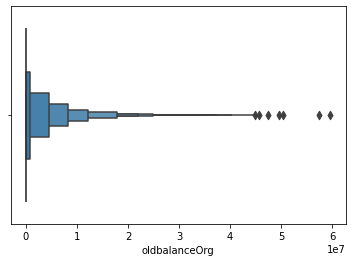

In [18]:
sns.boxenplot(df['oldbalanceOrg'])

D:\Apps\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='amount'>

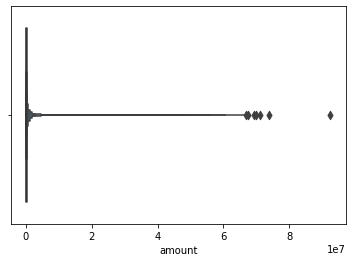

In [19]:
sns.boxenplot(df['amount']) 

D:\Apps\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='newbalanceOrig'>

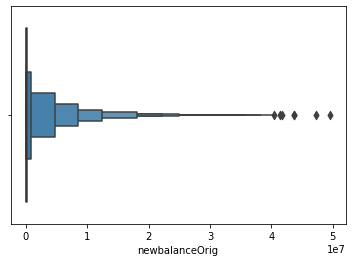

In [20]:
sns.boxenplot(df["newbalanceOrig"])

D:\Apps\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='oldbalanceDest'>

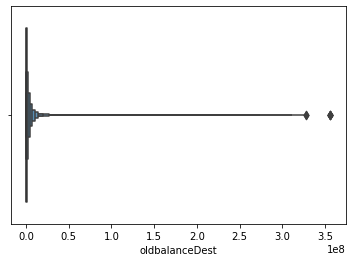

In [21]:
sns.boxenplot(df["oldbalanceDest"])

D:\Apps\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='newbalanceDest'>

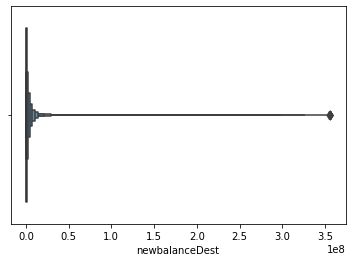

In [22]:
sns.boxenplot(df["newbalanceDest"])

In [23]:
# Remove Outliers

In [24]:
df['amount'].quantile(0.25)

13389.57

In [25]:
df['amount'].quantile(0.75)

208721.4775

In [26]:
# Make a function of outlier removal

In [27]:
def outlier_remve(dataframe,column_name):
    LQ = dataframe[column_name].quantile(0.25)
    UQ = dataframe[column_name].quantile(0.75)
    IQR = UQ - LQ
    Lower_Whisker = LQ - 1.5*IQR
    Upper_Whisker = UQ + 1.5*IQR
    new_df = dataframe.loc[(dataframe[column_name]>Lower_Whisker) & (dataframe[column_name]<Upper_Whisker)]
    return new_df[column_name]

In [28]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')

In [29]:
# Applying the outlier remove function on different  features of dataset

In [30]:
df['amount'] = outlier_remve(df,'amount')

In [31]:
df["oldbalanceOrg"] = outlier_remve(df,"oldbalanceOrg")

In [32]:
df["newbalanceOrig"] = outlier_remve(df,"newbalanceOrig")

In [33]:
df["oldbalanceDest"] = outlier_remve(df,"oldbalanceDest")

In [34]:
df["newbalanceDest"] = outlier_remve(df,"newbalanceDest")

# Question 2 ------  Describe your fraud detection model in elaboration.

In [35]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [36]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.024542e+06,5.250113e+06,5.309229e+06,5.576485e+06,5.624093e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.115342e+05,3.066377e+04,3.477113e+04,3.526762e+05,4.439104e+05,1.290820e-03,2.514687e-06
std,1.423320e+02,1.203983e+05,5.327502e+04,7.541065e+04,5.501108e+05,6.521958e+05,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.236854e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,6.317582e+04,4.260070e+03,0.000000e+00,1.883357e+04,1.076872e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,1.829338e+05,3.533994e+04,1.956409e+04,5.097021e+05,6.587419e+05,0.000000e+00,0.000000e+00
max,7.430000e+02,5.017184e+05,2.682878e+05,3.606456e+05,2.357589e+06,2.779768e+06,1.000000e+00,1.000000e+00


In [37]:
df.groupby("type").sum()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
type,,,,,,,,
CASH_IN,342111075,2.215322e+11,2.630053e+10,8.345101e+10,6.674851e+11,6.552212e+11,0,0
CASH_OUT,539015395,3.591407e+11,5.263559e+10,2.076154e+10,1.015489e+12,1.424089e+12,4116,0
DEBIT,10293386,2.260830e+08,1.581071e+09,1.746790e+09,1.837108e+10,2.119667e+10,0,0
PAYMENT,525778430,2.809337e+10,6.926294e+10,7.676771e+10,0.000000e+00,0.000000e+00,0,0
TRANSFER,131445897,6.294999e+10,1.120814e+10,1.880838e+09,2.653488e+11,3.960864e+11,4097,16


In [38]:
df.groupby("type").describe().T

type                       CASH_IN      CASH_OUT         DEBIT       PAYMENT  \
step           count  1.399284e+06  2.237500e+06  41432.000000  2.151495e+06   
               mean   2.444901e+02  2.409007e+02    248.440481  2.443782e+02   
               std    1.429260e+02  1.407754e+02    149.843650  1.426951e+02   
               min    1.000000e+00  1.000000e+00      1.000000  1.000000e+00   
               25%    1.560000e+02  1.550000e+02    153.000000  1.560000e+02   
...                            ...           ...           ...           ...   
isFlaggedFraud min    0.000000e+00  0.000000e+00      0.000000  0.000000e+00   
               25%    0.000000e+00  0.000000e+00      0.000000  0.000000e+00   
               50%    0.000000e+00  0.000000e+00      0.000000  0.000000e+00   
               75%    0.000000e+00  0.000000e+00      0.000000  0.000000e+00   
               max    0.000000e+00  0.000000e+00      0.000000  0.000000e+00   

type                       TRANSFER  
step           count  532909.000000  
               mean      246.657304  
               std       145.015876  
               min         1.000000  
               25%       156.000000  
...                             ...  
isFlaggedFraud min         0.000000  
               25%         0.000000  
               50%         0.000000  
               75%         0.000000  
               max         1.000000  

[64 rows x 5 columns]

In [39]:
df.groupby('isFraud').describe().T

isFraud                          0             1
step           count  6.354407e+06  8.213000e+03
               mean   2.432357e+02  3.684139e+02
               std    1.421402e+02  2.163887e+02
               min    1.000000e+00  1.000000e+00
               25%    1.560000e+02  1.810000e+02
               50%    2.390000e+02  3.670000e+02
               75%    3.340000e+02  5.580000e+02
               max    7.180000e+02  7.430000e+02
amount         count  6.020183e+06  4.359000e+03
               mean   1.114888e+05  1.742142e+05
               std    1.203715e+05  1.395276e+05
               min    1.000000e-02  0.000000e+00
               25%    1.235936e+04  5.458400e+04
               50%    6.311140e+04  1.392102e+05
               75%    1.828708e+05  2.727914e+05
               max    5.017184e+05  5.014963e+05
oldbalanceOrg  count  5.246866e+06  3.247000e+03
               mean   3.061867e+04  1.035431e+05
               std    5.322654e+04  7.660759e+04
               min    0.000000e+00  0.000000e+00
               25%    0.000000e+00  3.630025e+04
               50%    4.214000e+03  9.034605e+04
               75%    3.523900e+04  1.616706e+05
               max    2.682878e+05  2.682304e+05
newbalanceOrig count  5.301171e+06  8.058000e+03
               mean   3.482372e+04  1.697225e+02
               std    7.545536e+04  7.087570e+03
               min    0.000000e+00  0.000000e+00
               25%    0.000000e+00  0.000000e+00
               50%    0.000000e+00  0.000000e+00
               75%    1.968950e+04  0.000000e+00
               max    3.606456e+05  3.538742e+05
oldbalanceDest count  5.568738e+06  7.747000e+03
               mean   3.529446e+05  1.597700e+05
               std    5.502482e+05  3.958849e+05
               min    0.000000e+00  0.000000e+00
               25%    0.000000e+00  0.000000e+00
               50%    1.929791e+04  0.000000e+00
               75%    5.102959e+05  6.810598e+04
               max    2.357589e+06  2.350433e+06
newbalanceDest count  5.616979e+06  7.114000e+03
               mean   4.440170e+05  3.596682e+05
               std    6.522118e+05  6.338519e+05
               min    0.000000e+00  0.000000e+00
               25%    0.000000e+00  0.000000e+00
               50%    1.079543e+05  0.000000e+00
               75%    6.589171e+05  4.654739e+05
               max    2.779768e+06  2.776135e+06
isFlaggedFraud count  6.354407e+06  8.213000e+03
               mean   0.000000e+00  1.948131e-03
               std    0.000000e+00  4.409731e-02
               min    0.000000e+00  0.000000e+00
               25%    0.000000e+00  0.000000e+00
               50%    0.000000e+00  0.000000e+00
               75%    0.000000e+00  0.000000e+00
               max    0.000000e+00  1.000000e+00

D:\Apps\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='isFraud', ylabel='count'>

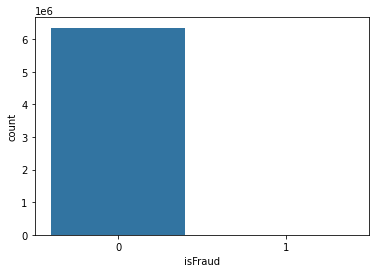

In [40]:
sns.countplot(df['isFraud'])

D:\Apps\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='isFlaggedFraud', ylabel='count'>

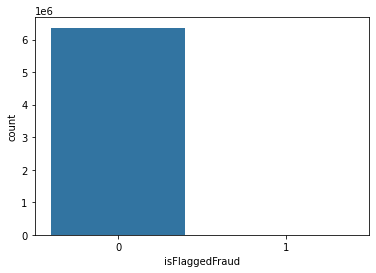

In [41]:
sns.countplot(df["isFlaggedFraud"])

D:\Apps\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='type', ylabel='count'>

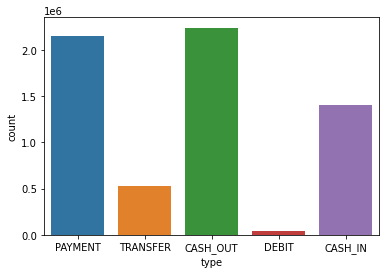

In [42]:
sns.countplot(df["type"])

In [43]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')

D:\Apps\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='isFlaggedFraud', ylabel='count'>

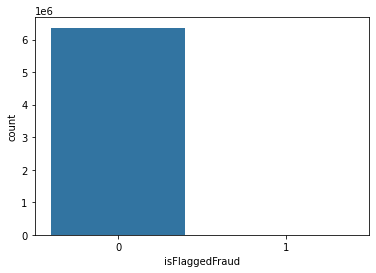

In [44]:
sns.countplot(df["isFlaggedFraud"])

In [45]:
# Drawing pie chart to show distribution of fraud and not fraud

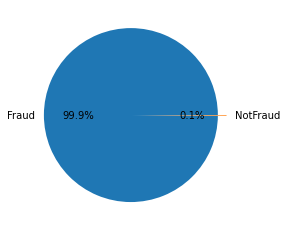

In [46]:
val = df['isFraud'].value_counts().values
col = ['Fraud','NotFraud']
notation = (0,0.1)
plt.pie(val,labels = col,explode = notation,autopct = '%1.1f%%')
plt.show()

In [47]:
# 5 different words in type feature

In [48]:
df['type'].nunique()

5

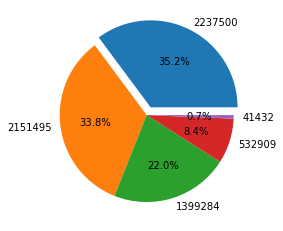

In [49]:
val = df['type'].value_counts().values
col = df['type'].value_counts().values
notation = (0.1,0,0,0,0)
plt.pie(val,labels = col,explode = notation,autopct = '%1.1f%%')
plt.show()

D:\Apps\Anaconda\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='amount', ylabel='Density'>

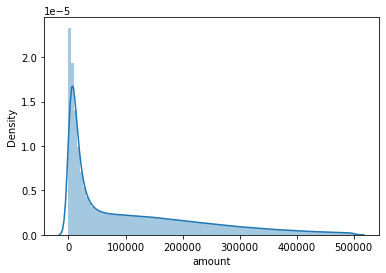

In [50]:
sns.distplot(df['amount'],bins = 100)

In [51]:
# Drawing regression plot

<AxesSubplot:xlabel='oldbalanceOrg', ylabel='newbalanceOrig'>

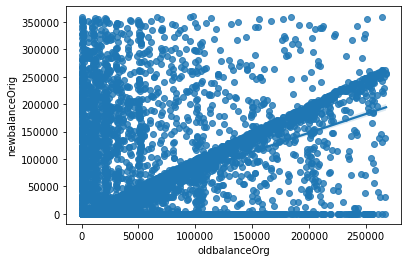

In [52]:
sns.regplot(x = "oldbalanceOrg",y = "newbalanceOrig",data= df.sample(20000))

In [53]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [54]:
# Filling the na values

In [40]:
df['amount'].fillna(df['amount'].mean(),inplace = True)

In [41]:
df['oldbalanceOrg'].fillna(df['oldbalanceOrg'].mean(),inplace = True)

In [42]:
df['newbalanceOrig'].fillna(df['newbalanceOrig'].mean(),inplace = True)

In [43]:
df['oldbalanceDest'].fillna(df['oldbalanceDest'].mean(),inplace = True)

In [44]:
df['newbalanceDest'].fillna(df['newbalanceDest'].mean(),inplace = True)

In [45]:
# Performing One-Jot Encoding on type to seperate the different classes in type

In [46]:
diff_payment_method = pd.get_dummies(df['type'],prefix = 'type',drop_first=True)
df = pd.concat([df,diff_payment_method],axis = 1)
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,0,0,1,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,0,0,1,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,0,0,0,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,1,0,0,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,0,0,1,0


In [47]:
df.dtypes

step                int64
type               object
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
type_CASH_OUT       uint8
type_DEBIT          uint8
type_PAYMENT        uint8
type_TRANSFER       uint8
dtype: object

In [47]:
df.drop('type',axis = 1,inplace = True)

In [48]:
# We need to convert the uint8 to int64 for performing the calculation easy

In [49]:
df['type_CASH_OUT'] = df['type_CASH_OUT'].astype(np.int64)
df['type_DEBIT'] = df['type_DEBIT'].astype(np.int64)
df['type_PAYMENT'] = df['type_PAYMENT'].astype(np.int64)
df['type_TRANSFER'] = df['type_TRANSFER'].astype(np.int64)

In [51]:
df.dtypes

step                int64
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
type_CASH_OUT       int64
type_DEBIT          int64
type_PAYMENT        int64
type_TRANSFER       int64
dtype: object

In [52]:
# Now make out training data and target data

In [50]:
x = df.drop('isFraud',axis = 1)
y = df['isFraud']

In [51]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = 42)

In [52]:
# Standarization 

In [53]:
x_train = MinMaxScaler().fit_transform(x_train)
x_test = MinMaxScaler().fit_transform(x_test)

# Question 4. Demonstrate the performance of the model by using best set of tools.

In [148]:
# Now  we will do model building using different machine learning algorithms

# Logistic Regression

In [149]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
predict = lr.predict(x_test)
print('F1 Score:',f1_score(y_test,predict))
print('Confusion Matrix: \n',confusion_matrix(y_test,predict))
print('ROC AUC Score:',roc_auc_score(y_test,predict))
print("Accuracy_score",accuracy_score(y_test,predict))

D:\Apps\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


F1 Score: 0.015273311897106108
Confusion Matrix: 
 [[1906317       5]
 [   2445      19]]
ROC AUC Score: 0.5038542080546428
Accuracy_score 0.9987164616672587


# Decision Tree

In [150]:
dtree = DecisionTreeClassifier()
dtree.fit(x_train,y_train)

DecisionTreeClassifier()

In [151]:
dtree_predict = dtree.predict(x_test)
dtree_predict

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [152]:
print("ROC_AUC_score:",roc_auc_score(y_test,dtree_predict))
print("Confusion Matrix\n",confusion_matrix(y_test,dtree_predict))
print("f1_score:",f1_score(y_test,dtree_predict))
print("classification_report:",classification_report(y_test,dtree_predict))
print("accuracy_score:",accuracy_score(y_test,dtree_predict))

ROC_AUC_score: 0.9112181378779212
Confusion Matrix
 [[1905922     400]
 [    437    2027]]
f1_score: 0.8288693518707831
classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.84      0.82      0.83      2464

    accuracy                           1.00   1908786
   macro avg       0.92      0.91      0.91   1908786
weighted avg       1.00      1.00      1.00   1908786

accuracy_score: 0.9995615013940798


# K Nearest Neighbours

In [154]:
knn_model = KNeighborsClassifier(n_neighbors = 6)
knn_model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=6)

In [156]:
knn_model_pred = knn_model.predict(x_test)
knn_model_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [159]:
print("Classification Report:\n",classification_report(y_test,knn_model_pred))
print("Accuracy Score:\n",accuracy_score(y_test,knn_model_pred))
print("F1 Score:",f1_score(y_test,knn_model_pred))
print("ROC AUC Score:",roc_auc_score(y_test,knn_model_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,knn_model_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.91      0.61      0.73      2464

    accuracy                           1.00   1908786
   macro avg       0.96      0.80      0.86   1908786
weighted avg       1.00      1.00      1.00   1908786

Accuracy Score:
 0.9994174307648945
F1 Score: 0.7289127254997562
ROC AUC Score: 0.8033309997134347
Confusion Matrix:
 [[1906179     143]
 [    969    1495]]


# Support Vector Machine

In [78]:
svm = SVC()
X_train = np.array(pd.DataFrame(x_train).sample(n=100000))
Y_train = np.array(pd.DataFrame(y_train).sample(n=100000))
svm.fit(X_train,Y_train)

D:\Apps\Anaconda\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [79]:
X_test = np.array(pd.DataFrame(x_test).sample(n=50000))
svm_predict = svm.predict(X_test)
svm_predict

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [80]:
Y_test = np.array(pd.DataFrame(y_test).sample(n=50000))

In [81]:
print("Classification Report:\n",classification_report(Y_test,svm_predict))
print("Accuracy Score:",accuracy_score(Y_test,svm_predict))
print("F1 Score:",f1_score(Y_test,svm_predict))
print("ROC AUC Score:",roc_auc_score(Y_test,svm_predict))
print("Confusion Matrix:\n",confusion_matrix(Y_test,svm_predict))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     49939
           1       0.00      0.00      0.00        61

    accuracy                           1.00     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       1.00      1.00      1.00     50000

Accuracy Score: 0.99878
F1 Score: 0.0
ROC AUC Score: 0.5
Confusion Matrix:
 [[49939     0]
 [   61     0]]


D:\Apps\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Apps\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Apps\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# XGBoost Classifier

In [160]:
xgb = XGBClassifier()
xgb.fit(x_train,y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [161]:
xgb_predict = xgb.predict(x_test)
xgb_predict

array([0, 0, 0, ..., 0, 0, 0])

In [162]:
print("F1 score:\n",f1_score(y_test,xgb_predict))
print("Accuracy_Score:\n",accuracy_score(y_test,xgb_predict))
print("Confusion_matrix:\n",confusion_matrix(y_test,xgb_predict))
print("ROC_AUC_score:\n",roc_auc_score(y_test,xgb_predict))
print("Classification_Report:\n",classification_report(y_test,xgb_predict)) 

F1 score:
 0.7033081531648866
Accuracy_Score:
 0.9994032856485745
Confusion_matrix:
 [[1906297      25]
 [   1114    1350]]
ROC_AUC_score:
 0.7739382480654221
Classification_Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.98      0.55      0.70      2464

    accuracy                           1.00   1908786
   macro avg       0.99      0.77      0.85   1908786
weighted avg       1.00      1.00      1.00   1908786



# Logistic Regression using different hyperparameters

In [76]:
lr = LogisticRegression(C = 10.0,solver = 'saga')
lr.fit(x_train,y_train)

LogisticRegression(C=10.0, solver='saga')

In [77]:
lr_predict = lr.predict(x_test)
lr_predict

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [78]:
print("Classification_report:..\n",classification_report(y_test,lr_predict))
print("ROC_AUC_SCORE:..\n",roc_auc_score(y_test,lr_predict))
print("Confusion_matrix:...,\n",confusion_matrix(y_test,lr_predict))
print("F1_score:,,,,...\n",f1_score(y_test,lr_predict))
print("Accuracy_score:....\n",accuracy_score(y_test,lr_predict))

Classification_report:..
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.76      0.01      0.02      2464

    accuracy                           1.00   1908786
   macro avg       0.88      0.50      0.51   1908786
weighted avg       1.00      1.00      1.00   1908786

ROC_AUC_SCORE:..
 0.5044624497180584
Confusion_matrix:...,
 [[1906315       7]
 [   2442      22]]
F1_score:,,,,...
 0.01764941837144003
Accuracy_score:....
 0.9987169855604557


# Decision tree using hyperparametrs

In [80]:
dtree = DecisionTreeClassifier(criterion='gini',splitter='random')
dtree.fit(x_train,y_train)
dtree_predict = dtree.predict(x_test)
dtree_predict

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [82]:
print("ROC AUC Score:",roc_auc_score(y_test,dtree_predict))
print("Confusion Matrix:\n",confusion_matrix(y_test,dtree_predict))
print("F1 Score:",f1_score(y_test,dtree_predict))
print("Classification Report:\n",classification_report(y_test,dtree_predict))
print("Accuracy Score:",accuracy_score(y_test,dtree_predict))

ROC AUC Score: 0.8843668522983751
Confusion Matrix:
 [[1905672     650]
 [    569    1895]]
F1 Score: 0.7566380515072868
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.74      0.77      0.76      2464

    accuracy                           1.00   1908786
   macro avg       0.87      0.88      0.88   1908786
weighted avg       1.00      1.00      1.00   1908786

Accuracy Score: 0.9993613741928116


# KNN using grid Search cv

In [66]:
param_grid = {'n_neighbors': [1,2,3],
             'weights': ['uniform','distance'],
             'algorithm': ['auto','ball_tree','kd_tree'],
             'p': [1,2]}

X_train = np.array(pd.DataFrame(x_train).sample(n=100000))
Y_train = np.array(pd.DataFrame(y_train).sample(n=100000))

Gridsearch_knn = GridSearchCV(KNeighborsClassifier(),param_grid,refit = True,verbose=3)
Gridsearch_knn.fit(X_train,Y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


D:\Apps\Anaconda\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


[CV 1/5] END algorithm=auto, n_neighbors=1, p=1, weights=uniform;, score=0.997 total time=   4.9s


D:\Apps\Anaconda\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


[CV 2/5] END algorithm=auto, n_neighbors=1, p=1, weights=uniform;, score=0.998 total time=   2.7s


...

[CV 4/5] END algorithm=kd_tree, n_neighbors=3, p=2, weights=distance;, score=0.999 total time=   2.6s


D:\Apps\Anaconda\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


[CV 5/5] END algorithm=kd_tree, n_neighbors=3, p=2, weights=distance;, score=0.999 total time=   2.9s


D:\Apps\Anaconda\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree'],
                         'n_neighbors': [1, 2, 3], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             verbose=3)

In [76]:
Gridsearch_knn.best_estimator_

KNeighborsClassifier(n_neighbors=2, p=1)

In [77]:
knn = KNeighborsClassifier(n_neighbors=2,algorithm='auto',p=1,weights='distance')
knn.fit(X_train,Y_train)
X_test = np.array(pd.DataFrame(x_test).sample(n=50000))
knn_predict = knn.predict(X_test)
knn_predict

Y_test = np.array(pd.DataFrame(y_test).sample(n=50000))
print("ROC AUC Score:",roc_auc_score(Y_test,knn_predict))
print("Confusion Matrix:\n",confusion_matrix(Y_test,knn_predict))
print("F1 Score:",f1_score(Y_test,knn_predict))
print("Classification Report:\n",classification_report(Y_test,knn_predict))
print("Accuracy Score:",accuracy_score(Y_test,knn_predict))


D:\Apps\Anaconda\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


ROC AUC Score: 0.4994991184484693
Confusion Matrix:
 [[49862    50]
 [   88     0]]
F1 Score: 0.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     49912
           1       0.00      0.00      0.00        88

    accuracy                           1.00     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       1.00      1.00      1.00     50000

Accuracy Score: 0.99724


# Now checking best accuracy from all models

###### Logistic regression

In [87]:
a = 0.9987164616672587

###### Decision Tree

In [88]:
b = 0.9995615013940798

###### KNN 

In [89]:
c = 0.9994174307648945

######  SVM

In [90]:
d = 0.99878

###### XGBoost

In [91]:
e = 0.9994032856485745

###### Logistic Regression using different hyperparameters

In [92]:
f = 0.9987169855604557

###### Decision tree using hyperparametrs

In [93]:
g = 0.9993613741928116

##### KNN using grid Search cv

In [94]:
h = 0.99724

# The Maximum accuracy is showed by decision tree

In [95]:
max(a,b,c,d,e,f,g,h)

0.9995615013940798

# The worst accuracy is shown by knn using grid search cv

In [98]:
min(a,b,c,d,e,f,g,h)

0.99724

# Project Completed 

# Made by - Swetanshu Pandey